In [1]:
import numpy as np
import pandas as pd

import statsmodels.formula.api as smf
from scipy.stats import norm

import matplotlib.pyplot as plt

## Topic Review

Knowing the reason the data is missing is the key to handle missing data in order to minimizing bias.
There are four general categories of missing data mechanism:

#### **Missing Data Mechanism**
- Missingness completely at random (MCAR)
  - There's no pattern of missingness in the data. The probability of missingness is the same for all unit,
- Missingness at random (MAR)
  - The pattern of missing can be seen from the observed data. The probability of missing depend only on available information
- Missingness that depends on unobserved predictors
  - Missingness is no longer random because it depends on information that has not been recorded
- Missingness that depends on the missing value itself
  - Missingness depend on the (potentially missing) variable itself

Imputation helper functions

In [2]:
def impute(data, value):
    """
    Function to impute a missing data (array-like) with a certain value

    :param data: array-like, the data with missing values
    :param value: float/int, the value to use for imputing missing values
    :return imputed_array: array-like, the imputed data
    """
    # Check for each element in data
    # return True if it's a missing values (represented as NaN in numpy)
    # return False otherwise.
    bool_nan = np.isnan(data)

    # Return the value a_impute where a is missing and returns a otherwise
    imputed_data = np.where(bool_nan, value, data)

    return imputed_data

# Missing Data Handling in Air Quality Dataset

The `airquality` dataset records daily air quality measurements in New York (May-September). We want to build
a regression model to explain `Ozone` level using other variables such as `Solar.R`, `Wind`, and `Temp`.
But we face the problem of missing data in the outcome (`Ozone`) and in one of the predictors (`Solar.R`).

- We will demonstrate how to handle **single variable missing data** (missing in one variable at a time) in two different ways:
  1. Discard / Delete Data (Complete Case Analysis)
  2. Imputation
     - Using deterministic regression imputation
     - Using random regression imputation
- Then we compare the evaluation of the regression models and see which method has the best performance

In [4]:
# load data
AQ = pd.read_csv('airquality.csv')

### Inspect What's Missing

In [5]:
AQ.isna().sum()

rownames     0
Ozone       37
Solar.R      7
Wind         0
Temp         0
Month        0
Day          0
dtype: int64

Calculate the percentage of missing

In [6]:
AQ.isna().sum()/AQ.shape[0]

rownames    0.000000
Ozone       0.241830
Solar.R     0.045752
Wind        0.000000
Temp        0.000000
Month       0.000000
Day         0.000000
dtype: float64

- `Ozone` has about 24% missing values
- `Solar.R` has about 5% missing values
- `Wind`, `Temp`, `Month`, and `Day` are fully observed, so they are good candidates as predictors to impute `Ozone`

## Handle Single Variable Missing

We will focus on handling the missing values in `Ozone` first,
and exclude `Solar.R` from the predictors for now since it has missing data of its own.

### 1. Discarding Data (Deletion): Complete Case Analysis

- The simplest way to handle missing data is discarding them
- This method is suitable if we assume the missingness of `Ozone` and `Solar.R` is completely at random (MCAR)
- We'll do complete case analysis by dropping rows that contain missing data

In [7]:
# Check the size of our original data

AQ.shape

(153, 7)

In [8]:
# Drop all rows that contain missing data
AQ_complete_case = AQ.dropna(axis = 0)

# Check the size of data after row deletion
AQ_complete_case.shape

(111, 7)

- We get the final complete data with fewer rows than the original data
- Then build the regression model and inspect the evaluation

#### Build Regression Model

- Use the data after we discard the missing value to build the model
- We do not include `Solar.R` variable first for simplicity of comparison with other handling methods, since `Solar.R` has missing data too

In [9]:
# Create OLS model object and fit the model

model_cca = smf.ols("Ozone ~ Wind + Temp + Month + Day",
                    AQ_complete_case).fit()

#### Store Evaluation of The Model

- Store rsquared and standard error,
- We then can compare the results with other handling data methods

In [10]:
r_squared = pd.DataFrame({"rsquared_cca" : [model_cca.rsquared]})
standard_error = pd.DataFrame({"standard_error_cca" : model_cca.bse})

In [11]:
r_squared

,rsquared_cca
0,0.608479


In [12]:
standard_error

,standard_error_cca
Intercept,23.877116
Wind,0.655177
Temp,0.263318
Month,1.501280
Day,0.233479


### 2. Imputation

- We know that `Wind`, `Temp`, `Month`, and `Day` are recorded for all days in the survey, so it's more plausible to assume
we can find the pattern of missingness of `Ozone` from these other, fully recorded variables.
- If we find the pattern of missingness of `Ozone` from the observed data, then the missingness is MAR, not completely random
- The best method if we assume MAR is to retain the data to do further analysis

#### 2.1 Impute missing Ozone using regression deterministic imputation

- Make sure to build the model include all predictors that **do not contain missing data**
- For now let's exclude `Solar.R` to predict `Ozone` since it has missing data

In [13]:
# Exclude other variables that contain missing value
AQ_predictors = AQ.drop(columns=['Solar.R'])

In [14]:
# Check percentage missing value
AQ_predictors.isna().sum()/AQ.shape[0]

rownames    0.00000
Ozone       0.24183
Wind        0.00000
Temp        0.00000
Month       0.00000
Day         0.00000
dtype: float64

We will only use the rows where `Ozone` and the predictors are complete

In [15]:
# Exclude Ozone missing cases
AQ_det = AQ_predictors.dropna(subset=['Ozone'])

In [16]:
# Check percentage missing value
AQ_det.isna().sum()/AQ.shape[0]

rownames    0.0
Ozone       0.0
Wind        0.0
Temp        0.0
Month       0.0
Day         0.0
dtype: float64

Build regression model for imputation using complete cases

In [17]:
# Create OLS model object and fit the model

model_imputation_reg = smf.ols("Ozone ~ Wind + Temp + Month + Day",
                               AQ_det).fit()

Make prediction of `Ozone` variable to impute the missing cases in `Ozone`

In [18]:
# Original dataset condition where Ozone still contain missing value

AQ.isna().sum()

rownames     0
Ozone       37
Solar.R      7
Wind         0
Temp         0
Month        0
Day          0
dtype: int64

In [19]:
# Get the data where Ozone is still missing, `AQ_predictors`

# Drop Ozone variable to do prediction

AQ_predictors = AQ_predictors.drop(columns=["Ozone"])

In [20]:
# Do Prediction

pred_ozone_det = model_imputation_reg.predict(AQ_predictors)

Imputation using the result of prediction

In [21]:
# Impute Ozone variable
# Store the complete Ozone that is imputed by deterministic value from regression prediction in new variable

AQ["imp_ozone_det_reg"] = impute(AQ['Ozone'], pred_ozone_det)

In [22]:
# Check total missing data where Ozone is imputed and stored in `imp_ozone_det_reg`

AQ.isna().sum()

rownames              0
Ozone                37
Solar.R               7
Wind                  0
Temp                  0
Month                 0
Day                   0
imp_ozone_det_reg     0
dtype: int64

- `imp_ozone_det_reg` has 0 missing data
- Then build the regression model and inspect the evaluation

##### Build Regression Model

- Use the imputed outcome to build the model
- Exclude `Solar.R` to predict `Ozone` since it has missing data

In [23]:
# Create OLS model object and fit the model
model_det_reg = smf.ols("imp_ozone_det_reg ~ Wind + Temp + Month + Day",
                        AQ).fit()

##### Store Evaluation of The Model

- Store R-squared and standard error,
- We then can compare the results with other handling data methods

In [24]:
r_squared["rsquared_det_reg"] = model_det_reg.rsquared
standard_error["standard_error_det_reg"] = model_det_reg.bse

In [25]:
r_squared

,rsquared_cca,rsquared_det_reg
0,0.608479,0.649442


In [26]:
standard_error

,standard_error_cca,standard_error_det_reg
Intercept,23.877116,17.503819
Wind,0.655177,0.480621
Temp,0.263318,0.195923
Month,1.501280,1.172254
Day,0.233479,0.171475


#### 2.2 Impute missing Ozone using random regression imputation

- We will try to do random regression imputation too
- To do it we store the residual standard deviation from the latest model

In [27]:
# residual standard deviation
sigma = np.sqrt(model_imputation_reg.mse_resid)

print(f"estimated residual standard deviation from the model: {np.round(sigma,1)}")

estimated residual standard deviation from the model: 21.4


Store each random prediction error from normal distribution

In [28]:
np.random.seed(1)

error = np.random.normal(0, sigma, len(AQ_predictors))

Do the prediction and add the prediction error

In [29]:
# Prediction results
pred_ozone_rand_reg = model_imputation_reg.predict(AQ_predictors) + error

# Impute missing Ozone with prediction results
AQ["imp_ozone_rand_reg"] = impute(AQ['Ozone'], pred_ozone_rand_reg)

In [30]:
# Check total missing data where Ozone is imputed and stored in `imp_ozone_rand_reg`

AQ.isna().sum()

rownames               0
Ozone                 37
Solar.R                7
Wind                   0
Temp                   0
Month                  0
Day                    0
imp_ozone_det_reg      0
imp_ozone_rand_reg     0
dtype: int64

- `imp_ozone_rand_reg` has 0 missing data
- Then build the regression model and inspect the evaluation

##### Build Regression Model

Use `imp_ozone_rand_reg` as the outcome

In [31]:
# Create OLS model object and fit the model
model_random_reg = smf.ols("imp_ozone_rand_reg ~ Wind + Temp + Month + Day",
                           AQ).fit()

##### Store Evaluation of The Model

- Store R-squared and standard error,
- We then can compare the results with other handling data methods

In [32]:
r_squared["rsquared_random_reg"] = model_random_reg.rsquared
standard_error["standard_error_random_reg"] = model_random_reg.bse

#### Performance and Standard Error Comparison

In [33]:
r_squared

,rsquared_cca,rsquared_det_reg,rsquared_random_reg
0,0.608479,0.649442,0.61124


- R-squared from the model that uses complete case analysis tends to be the lowest among the three
- Compare the R-squared of the model where `Ozone` is imputed by deterministic regression vs. random regression

In [34]:
standard_error

,standard_error_cca,standard_error_det_reg,standard_error_random_reg
Intercept,23.877116,17.503819,18.928573
Wind,0.655177,0.480621,0.519742
Temp,0.263318,0.195923,0.211871
Month,1.501280,1.172254,1.267671
Day,0.233479,0.171475,0.185433


- The standard error of the model that used complete case analysis (CCA) tends to be highest compared to the others
- Compare the standard error of the model where `Ozone` is imputed by deterministic regression vs. random regression

#### Distribution of Missing Data after Imputation

Here's the difference of the imputed values between the deterministic imputation and random imputation using regression

In [35]:
AQ[AQ["Ozone"].isna()][["Ozone","imp_ozone_det_reg","imp_ozone_rand_reg"]]

,Ozone,imp_ozone_det_reg,imp_ozone_rand_reg
4,NaN,-12.461546,6.066274
9,NaN,33.585741,28.246882
24,NaN,-11.888187,7.398559
25,NaN,-4.327333,-18.965507
26,NaN,14.905001,12.274000
31,NaN,46.478670,37.984432
32,NaN,35.002822,20.290897
33,NaN,1.058134,-17.037174
34,NaN,58.062387,43.691440
35,NaN,62.266472,61.995332


It's more clear if we compare the histograms of data and imputations

1. Observed Ozone

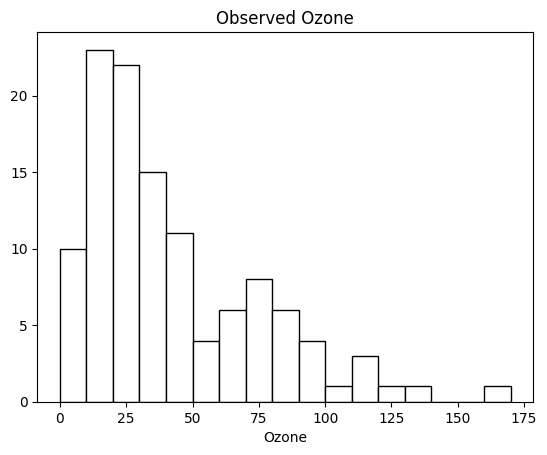

In [36]:
plt.hist(AQ[AQ["Ozone"].notna()]["Ozone"], bins = np.arange(0, 171, 10), color='white', edgecolor='black')
plt.xlabel('Ozone')
plt.title('Observed Ozone')
plt.show()

2. The result of deterministic imputation of Ozone using regression

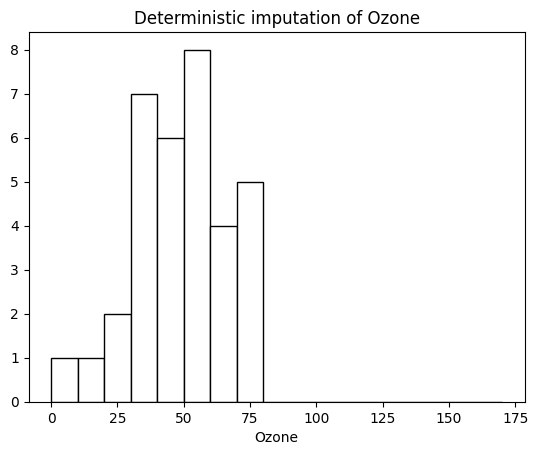

In [37]:
plt.hist(AQ[AQ["Ozone"].isnull()]["imp_ozone_det_reg"], bins = np.arange(0, 171, 10), color='white', edgecolor='black')
plt.xlabel('Ozone')
plt.title('Deterministic imputation of Ozone')
plt.show()

3. The result of random imputation of Ozone using regression

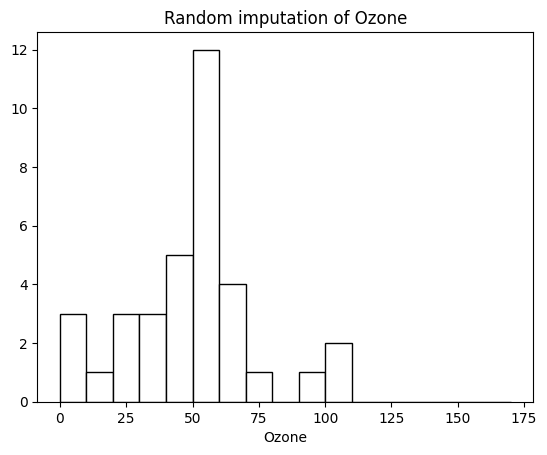

In [38]:
plt.hist(AQ[AQ["Ozone"].isnull()]["imp_ozone_rand_reg"], bins = np.arange(0, 171, 10), color='white', edgecolor='black')
plt.xlabel('Ozone')
plt.title('Random imputation of Ozone')
plt.show()

Random regression imputation gives more spread of imputed values than deterministic imputation

**Conclusion**

- We handled single-variable missing data (`Ozone`) in the airquality dataset using three approaches: Complete Case Analysis,
Deterministic Regression Imputation, and Random Regression Imputation
- Compare the R-squared and Standard Error tables above to decide which method gives the best performance for this dataset
- Deterministic regression imputation typically gives the smallest standard error because it removes the natural variability of the
missing values, while random regression imputation adds back some of that variability, and complete case analysis loses information
by discarding rows with missing data